In [1]:
import os

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
walk_dir = '/lustre/groups/ml01/projects/2022_multigrate_anastasia.litinetskaya/snakemake/hyperparam/data/multigrate/'

In [84]:
df = {}
i = 0

for root, subdirs, files in os.walk(walk_dir):
    for file in files:
        if file.endswith('.csv'):
            tmp = pd.read_csv(root+'/'+file, index_col=0)
            # print(file)
            if 'query' in root:
                result = {
                    "exp": root.split('/')[-4],
                    "acc": tmp['f1-score']['accuracy'],
                    "macro_avg": tmp['f1-score']['macro avg'],
                    "weighted_avg": tmp['f1-score']['weighted avg'],
                    "train_epoch": root.split('/')[-1].split('=')[1].split('-')[0],
                    "query_epoch": file.split('=')[1].split('-')[0],
                    "split": root.split('/')[-3],
                }
            else:
                result = {
                    "exp": root.split('/')[-3],
                    "acc": tmp['f1-score']['accuracy'],
                    "macro_avg": tmp['f1-score']['macro avg'],
                    "weighted_avg": tmp['f1-score']['weighted avg'],
                    "train_epoch": file.split('=')[1].split('-')[0],
                    "query_epoch": 0,
                    "split": root.split('/')[-2],
                }
            df[i] = result
            i +=1
                

In [85]:
df = pd.DataFrame(df).T
df

,exp,acc,macro_avg,weighted_avg,train_epoch,query_epoch,split
0,attention_dropout~False_attn_dim~8_batch_size~...,0.0096,0.004167,0.000302,49,0,3
1,attention_dropout~False_attn_dim~8_batch_size~...,0.005762,0.003076,0.000221,149,0,3
2,attention_dropout~False_attn_dim~8_batch_size~...,0.005762,0.003064,0.00022,99,0,3
3,attention_dropout~False_attn_dim~8_batch_size~...,0.005095,0.002465,0.000178,199,0,3
4,attention_dropout~False_attn_dim~8_batch_size~...,0.784263,0.462629,0.77374,99,199,3
...,...,...,...,...,...,...,...
595,attention_dropout~False_attn_dim~8_batch_size~...,0.655714,0.285555,0.621393,99,49,0
596,attention_dropout~False_attn_dim~8_batch_size~...,0.711783,0.44877,0.683059,199,149,0
597,attention_dropout~False_attn_dim~8_batch_size~...,0.711783,0.44877,0.683059,199,199,0
598,attention_dropout~False_attn_dim~8_batch_size~...,0.711783,0.44877,0.683059,199,99,0


In [86]:
df['train_epoch'] = df['train_epoch'].astype(int)
df['query_epoch'] = df['query_epoch'].astype(int)

In [87]:
df = df.groupby(['exp', 'train_epoch', 'query_epoch']).mean().reset_index().drop('split', axis=1)

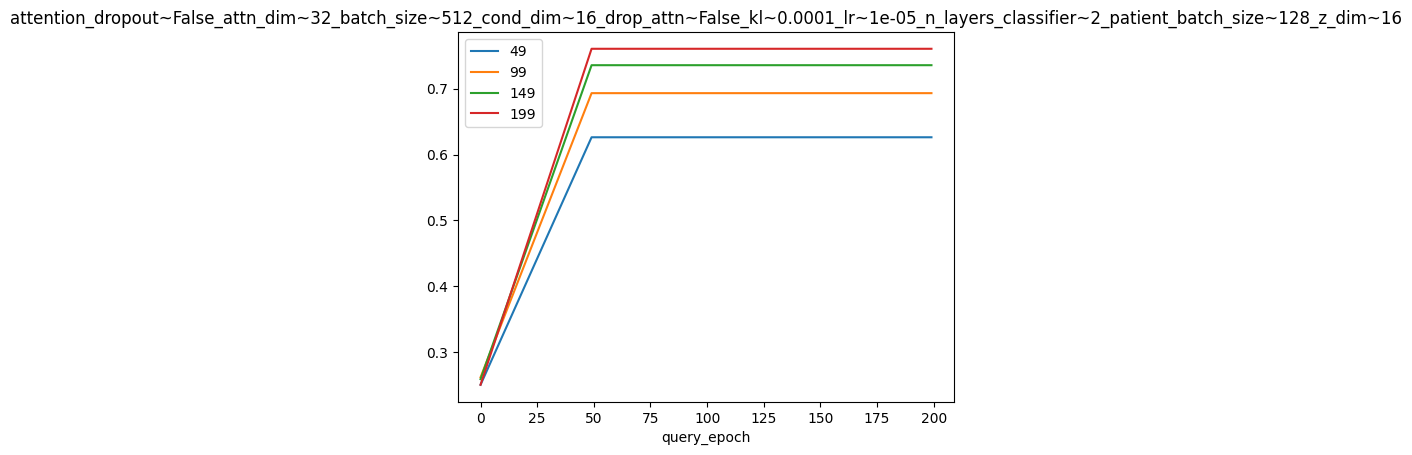

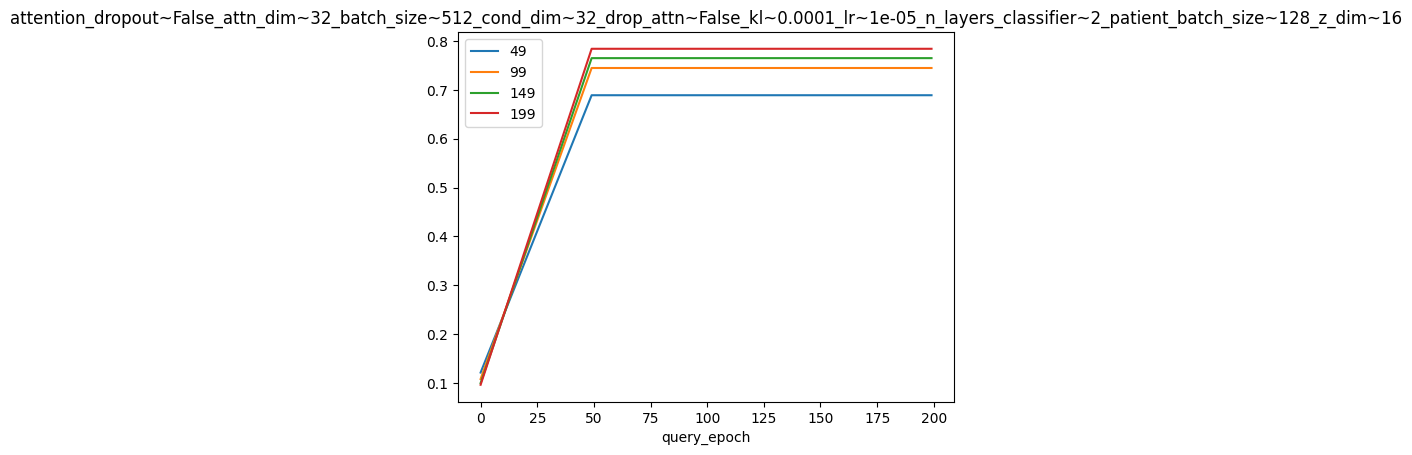

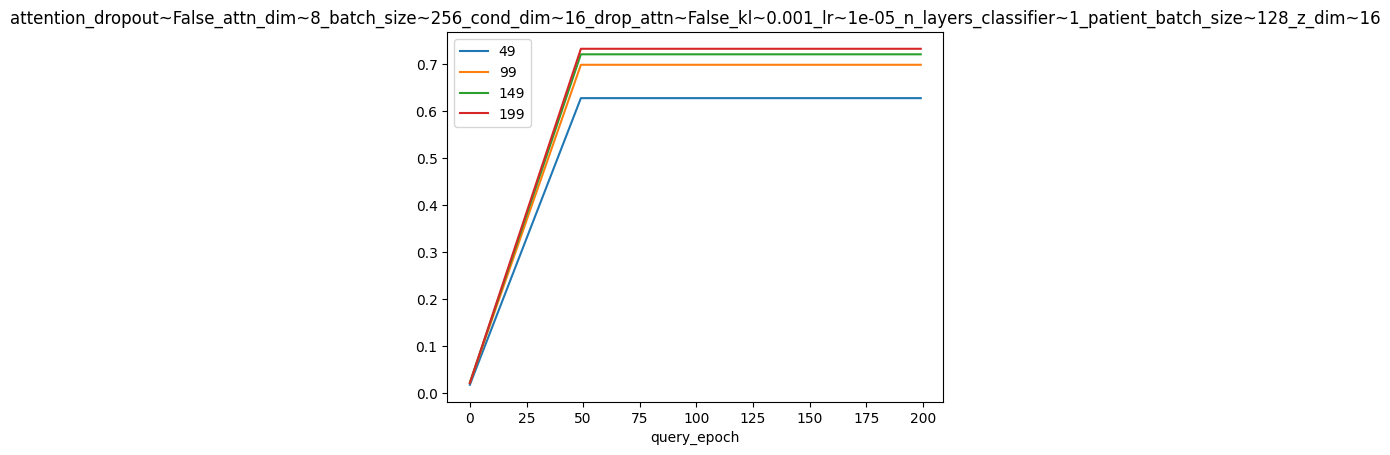

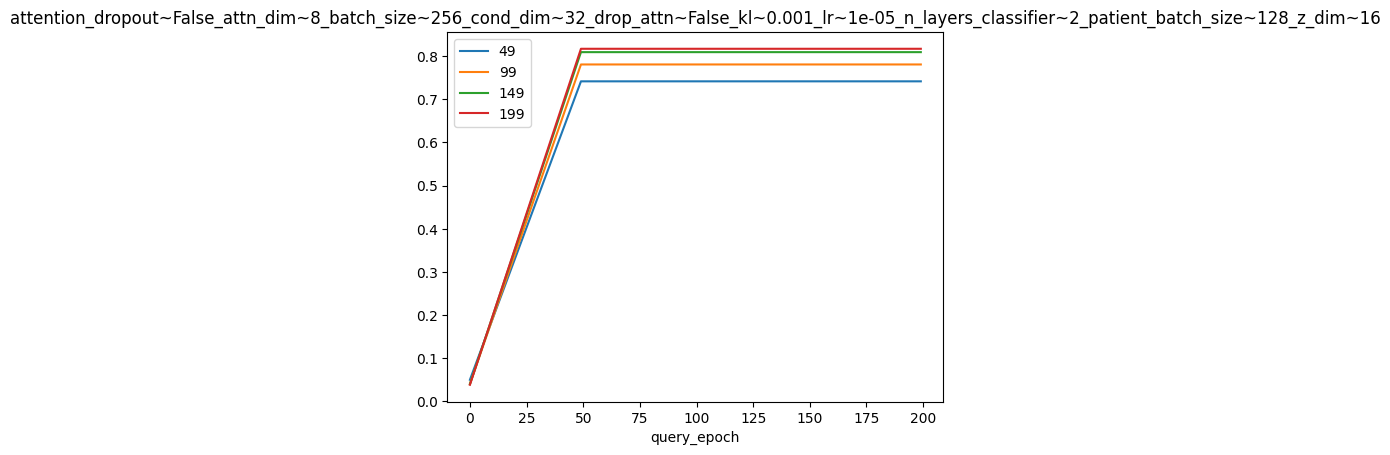

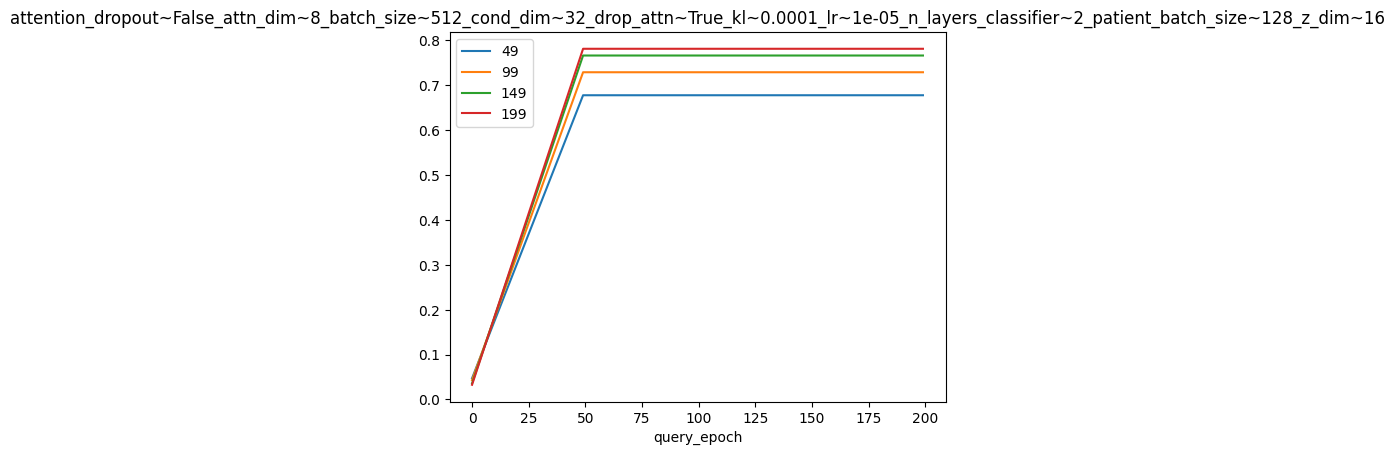

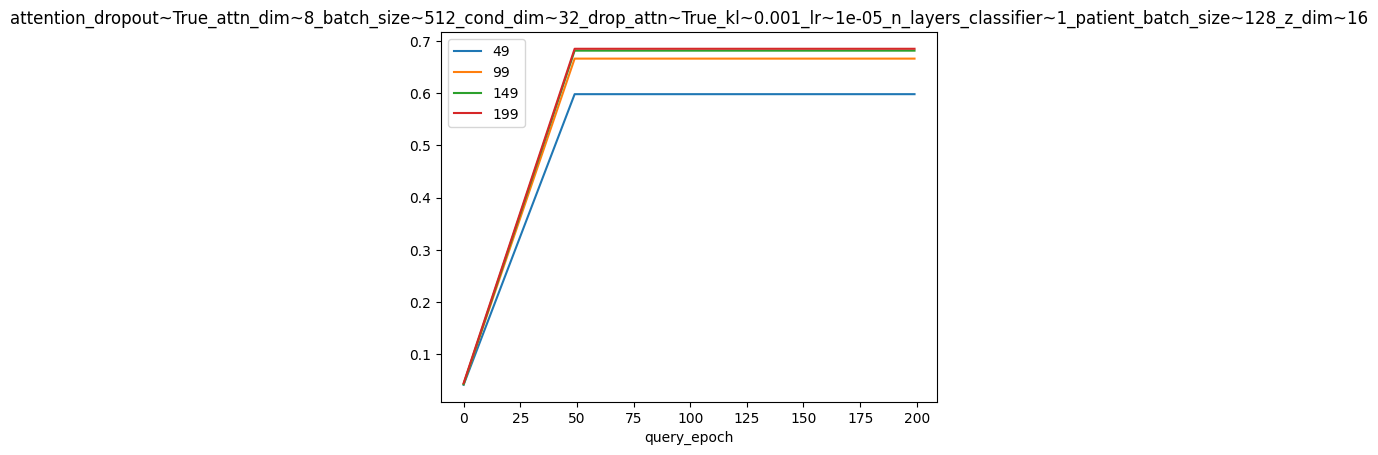

In [88]:
df['exp'] = df['exp'].astype('category')
for ex in df['exp'].cat.categories:
    plt.figure()
    tmp = df[df['exp'] == ex]
    tmp.set_index('query_epoch', inplace=True)
    tmp.groupby('train_epoch')['acc'].plot(legend=True, title=tmp['exp'].values[0])

# test data

In [31]:
exp = [0]*12 + [1]*12
train_ep = [50, 100] * 6 + [50, 100] * 6
q_ep = [0, 0, 1, 1, 2, 2] * 4
split = [0] * 6 + [1] * 6 + [0] * 6 + [1] * 6
acc = np.random.normal(size=24)

In [32]:
df = pd.DataFrame([exp, train_ep, q_ep, split, acc]).T
df.columns = ['exp', 'train_epoch', 'query_epoch', 'split', 'acc']
df

,exp,train_epoch,query_epoch,split,acc
0,0.0,50.0,0.0,0.0,0.400157
1,0.0,100.0,0.0,0.0,0.978738
2,0.0,50.0,1.0,0.0,2.240893
3,0.0,100.0,1.0,0.0,1.867558
4,0.0,50.0,2.0,0.0,-0.977278
5,0.0,100.0,2.0,0.0,0.950088
6,0.0,50.0,0.0,1.0,-0.151357
7,0.0,100.0,0.0,1.0,-0.103219
8,0.0,50.0,1.0,1.0,0.410599
9,0.0,100.0,1.0,1.0,0.144044


In [40]:
df.groupby(['exp', 'train_epoch', 'query_epoch']).mean()

split       acc
exp train_epoch query_epoch                 
0.0 50.0        0.0            0.5  0.124400
                1.0            0.5  1.325746
                2.0            0.5  0.238498
    100.0       0.0            0.5  0.437760
                1.0            0.5  1.005801
                2.0            0.5  0.855563
1.0 50.0        0.0            0.5 -0.366210
                1.0            0.5  0.493646
                2.0            0.5 -0.473662
    100.0       0.0            0.5 -1.054563
                1.0            0.5  1.179258
                2.0            0.5  1.291411

In [46]:
df = df.groupby(['exp', 'train_epoch', 'query_epoch']).mean().reset_index().drop('split', axis=1)

In [47]:
tmp = df[df['exp'] == 0]
tmp

,exp,train_epoch,query_epoch,acc
0,0.0,50.0,0.0,0.124400
1,0.0,50.0,1.0,1.325746
2,0.0,50.0,2.0,0.238498
3,0.0,100.0,0.0,0.437760
4,0.0,100.0,1.0,1.005801
5,0.0,100.0,2.0,0.855563


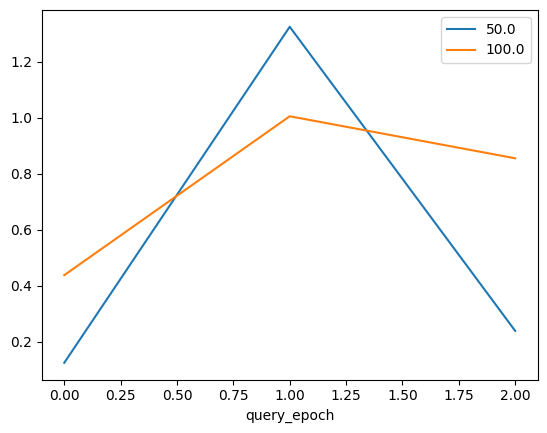

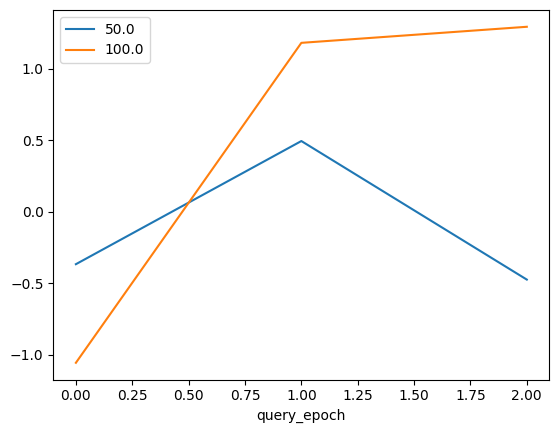

In [55]:
df['exp'] = df['exp'].astype('category')
for ex in df['exp'].cat.categories:
    plt.figure()
    tmp = df[df['exp'] == ex]
    tmp.set_index('query_epoch', inplace=True)
    tmp.groupby('train_epoch')['acc'].plot(legend=True)